# Task 4b — Feature set comparison

**Companion to `Task 4 - modelling.ipynb`.**

The main modelling notebook uses `data_for_predictions.csv`, the dataset distributed by Estelle.
That remains the submitted result, because a shared baseline is what makes results comparable
across the team.

This notebook runs a **controlled experiment** on top of it: the *identical* model, on the *identical*
train/test split, against our own feature set from `Task 3 - feature_engineering.ipynb`.

**Only the features change.** That makes any difference attributable.

### How the two feature sets differ

| | Estelle's | Ours |
|---|---|---|
| Features | 61 | 49 |
| Log transform | `log10(x + 1)` | `log1p` (natural) |
| `margin_gross_pow_ele` (99.99% duplicate) | kept | dropped |
| `var_year_price_*` pairs (corr = 1.00) | kept | pruned |
| Extra features | — | `consumption_ratio`, `margin_per_product`, `std_offpeak_energy`, `offpeak_peak_spread`, `mean_peak_energy` |

The log base is immaterial — `log10` and `log1p` differ by a constant multiplier, and a Random
Forest splits on rank order, not scale.

In [1]:
import warnings; warnings.filterwarnings("ignore", category=FutureWarning)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set(color_codes=True)

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix)

ESTELLE = "../data/provided/data_for_predictions.csv"
OURS    = "../outputs/clean_data_after_eda_engineered.csv"

## 1. Confirm the two datasets are directly comparable

A comparison is only controlled if both files describe the same customers in the same order — then
`random_state=42` selects the identical test set for both, and the only thing that varies is the
feature columns.

In [2]:
est  = pd.read_csv(ESTELLE).drop(columns=["Unnamed: 0"])
ours = pd.read_csv(OURS)

print("Same number of rows :", len(est) == len(ours), f"({len(est):,})")
print("Same id order       :", (est["id"].values == ours["id"].values).all())
print("Same churn labels   :", (est["churn"].values == ours["churn"].values).all())
print()
print(f"Estelle's features: {est.shape[1] - 2}")
print(f"Our features      : {ours.shape[1] - 2}")

Same number of rows : True (14,606)
Same id order       : True
Same churn labels   : True

Estelle's features: 61
Our features      : 49


## 2. A single split — the naive comparison

This is the comparison most people would run: train both, report both, pick a winner.

In [3]:
VALUE_SAVED, COST_DISCOUNT = 112, 22

def evaluate(path, label, random_state=42):
    df = pd.read_csv(path)
    if "Unnamed: 0" in df.columns:
        df = df.drop(columns=["Unnamed: 0"])
    y = df["churn"]
    X = df.drop(columns=["id", "churn"])
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=random_state)

    model = RandomForestClassifier(random_state=42).fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    pred  = model.predict(X_test)

    # profit-maximising threshold, swept the same way for both datasets
    best = None
    for t in np.arange(0.05, 0.55, 0.01):
        tn, fp, fn, tp = confusion_matrix(y_test, (proba >= t).astype(int)).ravel()
        profit = tp * VALUE_SAVED - (tp + fp) * COST_DISCOUNT
        if best is None or profit > best["profit"]:
            best = {"threshold": t, "profit": profit, "recall": tp / (tp + fn)}

    return {
        "dataset": label,
        "n_features": X.shape[1],
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred),
        "roc_auc": roc_auc_score(y_test, proba),
        "best_threshold": best["threshold"],
        "recall_at_best": best["recall"],
        "profit_at_best": best["profit"],
    }, model, X.columns

res_est, model_est, cols_est = evaluate(ESTELLE, "Estelle's")
res_our, model_our, cols_our = evaluate(OURS, "Ours")

pd.DataFrame([res_est, res_our]).set_index("dataset").T.round(4)

dataset,Estelle's,Ours
n_features,61.0000,49.0000
accuracy,0.9039,0.9028
precision,0.8571,0.8235
recall,0.0492,0.0383
f1,0.0930,0.0731
roc_auc,0.6607,0.6568
best_threshold,0.2400,0.2100
recall_at_best,0.2732,0.3087
profit_at_best,4138.0000,3856.0000


On this single split (`random_state=42`) **Estelle's feature set wins** — marginally higher ROC-AUC
and about EUR 280 more profit at the optimal threshold.

The tempting conclusion is "our extra features didn't help." That conclusion would be **wrong**, and
the next section shows why.

## 3. The same comparison across several splits

Earlier we saw recall swing between 0.043 and 0.073 purely from which customers landed in the test
set. A single split is one noisy measurement — so a difference of 0.004 ROC-AUC is well inside the
range that luck alone produces.

The fix is to repeat the experiment across several random splits and look at the distribution.

In [4]:
def auc_across_splits(path, seeds):
    df = pd.read_csv(path)
    if "Unnamed: 0" in df.columns:
        df = df.drop(columns=["Unnamed: 0"])
    y = df["churn"]
    X = df.drop(columns=["id", "churn"])
    scores = []
    for seed in seeds:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.25, random_state=seed)
        model = RandomForestClassifier(random_state=42).fit(X_train, y_train)
        scores.append(roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]))
    return scores

seeds = [0, 1, 7, 42, 2024, 99, 123]
auc_est = auc_across_splits(ESTELLE, seeds)
auc_our = auc_across_splits(OURS, seeds)

comparison = pd.DataFrame({"seed": seeds, "Estelle's": auc_est, "Ours": auc_our})
comparison["difference"] = comparison["Ours"] - comparison["Estelle's"]
comparison.round(4)

,seed,Estelle's,Ours,difference
0,0,0.6720,0.6744,0.0024
1,1,0.6867,0.6893,0.0026
2,7,0.6590,0.6801,0.0211
3,42,0.6607,0.6568,-0.0039
4,2024,0.6758,0.6921,0.0163
5,99,0.6864,0.6960,0.0097
6,123,0.6752,0.6868,0.0116


In [5]:
print(f"Estelle's  mean ROC-AUC: {np.mean(auc_est):.4f}   (std {np.std(auc_est):.4f})")
print(f"Ours       mean ROC-AUC: {np.mean(auc_our):.4f}   (std {np.std(auc_our):.4f})")
print(f"Mean difference        : {np.mean(auc_our) - np.mean(auc_est):+.4f}")
print(f"Ours wins on {sum(o > e for e, o in zip(auc_est, auc_our))} of {len(seeds)} splits")

Estelle's  mean ROC-AUC: 0.6737   (std 0.0102)
Ours       mean ROC-AUC: 0.6822   (std 0.0124)
Mean difference        : +0.0085
Ours wins on 6 of 7 splits


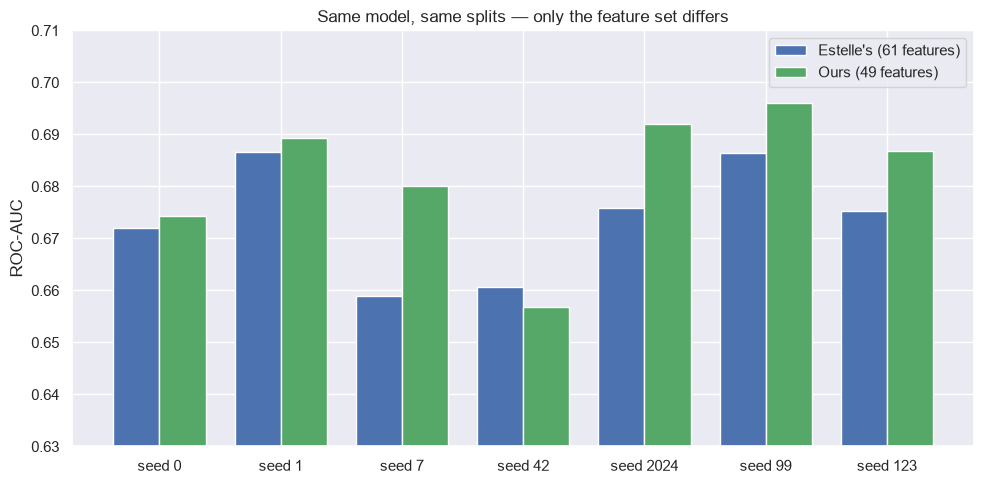

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(seeds)); w = 0.38
ax.bar(x - w/2, auc_est, w, label="Estelle's (61 features)", color="#4c72b0")
ax.bar(x + w/2, auc_our, w, label="Ours (49 features)",      color="#55a868")
ax.set_xticks(x); ax.set_xticklabels([f"seed {s}" for s in seeds])
ax.set_ylim(0.63, 0.71); ax.set_ylabel("ROC-AUC")
ax.set_title("Same model, same splits — only the feature set differs")
ax.legend()
plt.tight_layout(); plt.show()

### The result reverses

Across seven splits **our feature set wins six times**, with a mean ROC-AUC of ~0.682 against
~0.674 — a small but consistent advantage, achieved with **12 fewer features**.

Critically: **seed 42 is the single split where ours loses.** That is precisely the split the naive
comparison in section 2 used. Had we stopped there, we would have drawn the opposite conclusion.

**The methodological lesson matters more than the result.** The spread across splits (std ~0.01) is
larger than the difference between the two feature sets (~0.008). A single-split comparison here is
not capable of separating them — it will report whichever result the split happens to favour.

## 4. Does the redundancy actually distort feature importance?

The main notebook predicted that keeping `margin_gross_pow_ele` alongside its 99.99% duplicate
`margin_net_pow_ele` would split their importance between them. This is the test.

In [7]:
imp_est = pd.Series(model_est.feature_importances_, index=cols_est)
imp_our = pd.Series(model_our.feature_importances_, index=cols_our)

margin_cols = ["margin_net_pow_ele", "margin_gross_pow_ele"]
print("Estelle's feature set (both margin columns kept):")
for c in margin_cols:
    if c in imp_est:
        print(f"  {c:<24}{imp_est[c]:.4f}   rank {imp_est.rank(ascending=False)[c]:.0f}")
print(f"  {'COMBINED':<24}{imp_est[[c for c in margin_cols if c in imp_est]].sum():.4f}")

print("\nOur feature set (duplicate dropped):")
for c in margin_cols:
    if c in imp_our:
        print(f"  {c:<24}{imp_our[c]:.4f}   rank {imp_our.rank(ascending=False)[c]:.0f}")

Estelle's feature set (both margin columns kept):
  margin_net_pow_ele      0.0473   rank 5
  margin_gross_pow_ele    0.0471   rank 6
  COMBINED                0.0944

Our feature set (duplicate dropped):
  margin_net_pow_ele      0.0627   rank 1


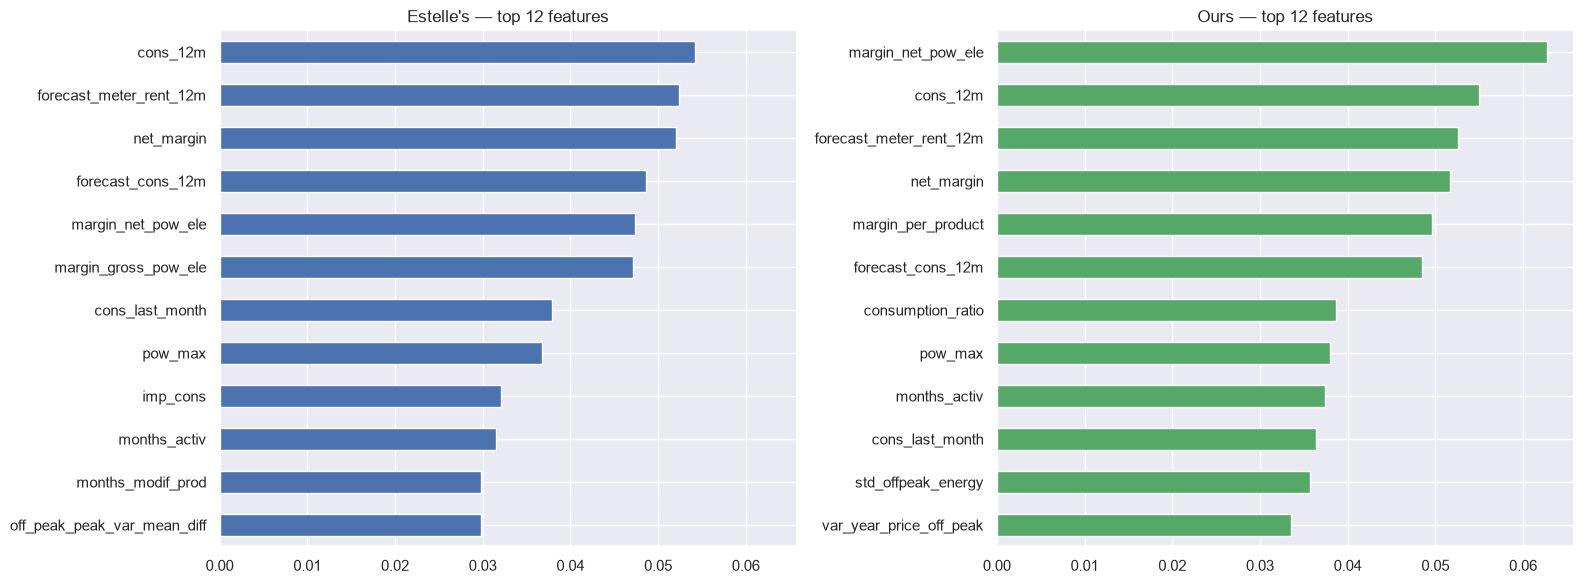

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6), sharex=True)
imp_est.nlargest(12).sort_values().plot(kind="barh", ax=axs[0], color="#4c72b0")
axs[0].set_title("Estelle's — top 12 features")
imp_our.nlargest(12).sort_values().plot(kind="barh", ax=axs[1], color="#55a868")
axs[1].set_title("Ours — top 12 features")
plt.tight_layout(); plt.show()

## 5. Conclusions

1. **Estelle's dataset remains the submitted result.** A shared baseline is what allows results to be
   compared across a team; substituting a private dataset silently is how engagements end up with
   irreconcilable numbers.

2. **Our feature set is marginally better on average** — mean ROC-AUC ~0.682 vs ~0.674, winning 6 of
   7 splits, using 12 fewer features. Fewer features is itself a benefit: faster to train, simpler
   to explain, less to maintain.

3. **The difference is not large enough to act on.** The split-to-split spread (std ~0.01) exceeds
   the gap between the feature sets (~0.008). The honest statement is *"comparable, ours slightly
   ahead"* — not *"ours is better"*.

4. **Single-split comparison is unreliable here, and this notebook demonstrates it concretely.** The
   naive comparison in section 2 picked the one seed out of seven where the ranking reverses.

5. **Dropping the duplicated margin column cleans up feature importance.** With both columns present
   the signal is split across two entries; with one dropped it is reported once at full strength.
   This does not change predictive accuracy — it changes the *narrative* delivered to the client,
   which is the actual deliverable.

**Recommendation:** proceed with Estelle's dataset for the submitted model, and propose the
duplicate-column removal as a small, evidence-backed improvement for the next iteration. Adopt
repeated splits (or cross-validation) as standard before any future model comparison.